In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def newton_fractal(func, dfunc, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                   resolution=500, max_iter=50, tol=1e-6):
    """
    roots : ndarray of complex
        Array of discovered root values.
    root_index : ndarray of shape (resolution, resolution)
        Integer index mapping each pixel to a root (0..len(roots)-1).
    iters : ndarray of shape (resolution, resolution)
        Number of iterations taken to converge (max_iter if not converged).
    img : ndarray
        Float image array (root index + normalized iteration) suitable for imshow.
    """
    re = np.linspace(xlim[0], xlim[1], resolution)
    im = np.linspace(ylim[0], ylim[1], resolution)
    Re, Im = np.meshgrid(re, im[::-1])  # flip im so image y axis is conventional
    z = Re + 1j * Im
    z = z.astype(np.complex128)
    
    # iteration trackers
    iters = np.full(z.shape, max_iter, dtype=int)
    converged = np.zeros(z.shape, dtype=bool)
    
    # Newton iterations (vectorized)
    for k in range(max_iter):
        # avoid division by zero: add tiny epsilon where derivative is zero
        derivative = dfunc(z) + 1e-12 # avoid div by 0
        # Newton step
        z_next = z - func(z) / derivative
        # check convergence using function value
        just_converged = (~converged) & (np.abs(func(z_next)) < tol)
        iters[just_converged] = k
        converged = converged | just_converged
        z = z_next
    
    # After iterations, group final z into distinct roots
    flat_z = z.ravel()
    flat_converged = converged.ravel()
    root_list = []
    root_index_flat = np.full(flat_z.shape, -1, dtype=int)
    root_tol = 1e-3  # tolerance for considering two z values the same root
    for i, val in enumerate(flat_z):
        assigned = False
        if not flat_converged[i]:
            root_index_flat[i] = -1
        else:
            for r_idx, r in enumerate(root_list):
                if np.abs(val - r) < root_tol:
                    root_index_flat[i] = r_idx
                    assigned = True
                    break
            if not assigned:
                root_list.append(val)
                root_index_flat[i] = len(root_list) - 1
    roots = np.array(root_list)
    root_index = root_index_flat.reshape(z.shape)
    return roots, root_index, iters

In [4]:
def e_surf(k_hats, qs, ms, Q, k):
    k = np.expand_dims(k,axis = -1)
    return sum(np.sqrt(np.sum((k_hat * k+q)**2, axis = -1) + m**2) for q, m, k_hat in zip(qs, ms, k_hats))+Q


def d_e_surf(k_hats, qs, ms, k):
    k = np.expand_dims(k,axis = -1)
    return sum(np.sum(k_hat*(k_hat * k + q), axis = -1)/np.sqrt(np.sum((k_hat * k + q)**2, axis = -1) + m**2) for q, m, k_hat in zip(qs, ms, k_hats))

In [5]:
from matplotlib.colors import hsv_to_rgb

def make_images(k_hat, qs, ms, Q, xlim, ylim, res, name):
    # Generate fractal
    roots, root_index, iters = newton_fractal(
    lambda k: e_surf(k_hat, qs, ms, Q, k),
    lambda k: d_e_surf(k_hat, qs, ms, k),
    xlim=xlim,
    ylim=ylim,
    resolution=res,
    max_iter=50,
    tol=1e-12,
    )

    print("Discovered roots (approx):")
    for i, r in enumerate(roots):
        print(f"root {i}: {r:.6f}")
    
    x = np.linspace(*xlim, res)
    y = np.linspace(*ylim, res)
    X, Y = np.meshgrid(x, y)
    xs = X + 1j*Y
    e_surface = 1/e_surf(k_hat, qs, ms, Q, xs)
    # magnitude → brightness
    mag = np.log(np.abs(e_surface)+0.01)
    mag = mag / mag.max()    # normalize to [0,1]
    mag = mag - mag.min()
    # phase → hue
    phase = np.angle(e_surface)
    phase = (phase + np.pi) / (2*np.pi)   # map [-pi,pi] to [0,1]

    # HSV image

    newton_fractal_factor = (root_index+1)/2
    hsv = np.zeros(e_surface.shape + (3,))
    hsv[..., 0] = phase
    hsv[..., 1] = 1
    hsv[..., 2] = mag

    img = hsv_to_rgb(hsv)

    plt.figure(figsize=(7, 7))
    plt.imshow(
        newton_fractal_factor, extent=xlim+ylim, origin="lower"
    )
    plt.xlabel("Re")
    plt.ylabel("Im")
    plt.scatter(roots.real, roots.imag, c='white')
    plt.tight_layout()
    plt.savefig(f'../images/newton/newton_{name}.png', dpi = 300)
    plt.show()

    plt.figure(figsize=(7, 7))
    plt.imshow(
        img, extent=xlim+ylim, origin="lower"
    )
    plt.xlabel("Re")
    plt.ylabel("Im")
    plt.tight_layout()
    plt.savefig(f'../images/newton/integrand_{name}.png', dpi = 300)

Discovered roots (approx):
root 0: 5.808366+6.463683j
root 1: 4.696563-6.576371j


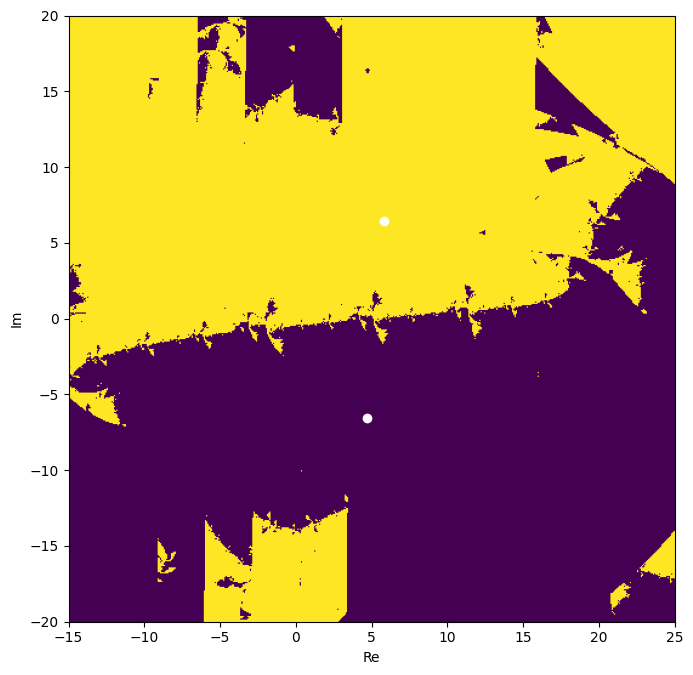

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.1539151157838914].


Discovered roots (approx):
root 0: 5.849089+6.876330j
root 1: 4.785409-7.016722j


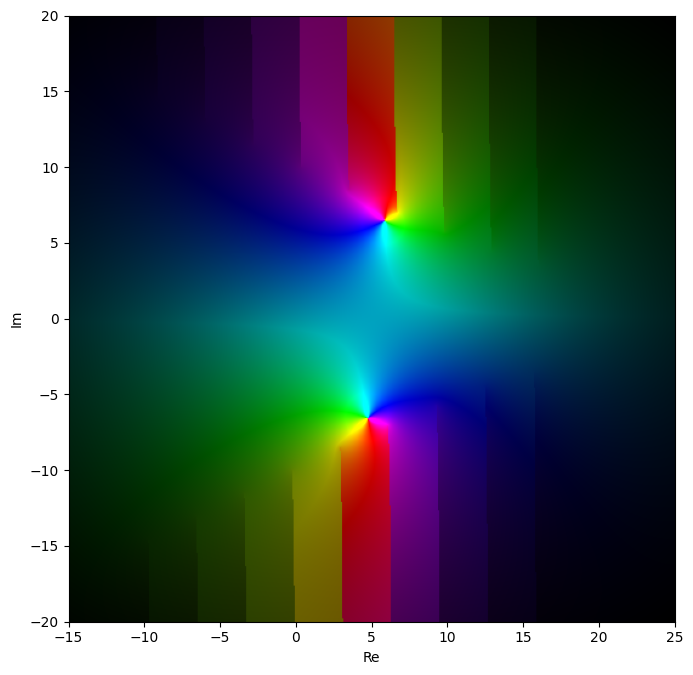

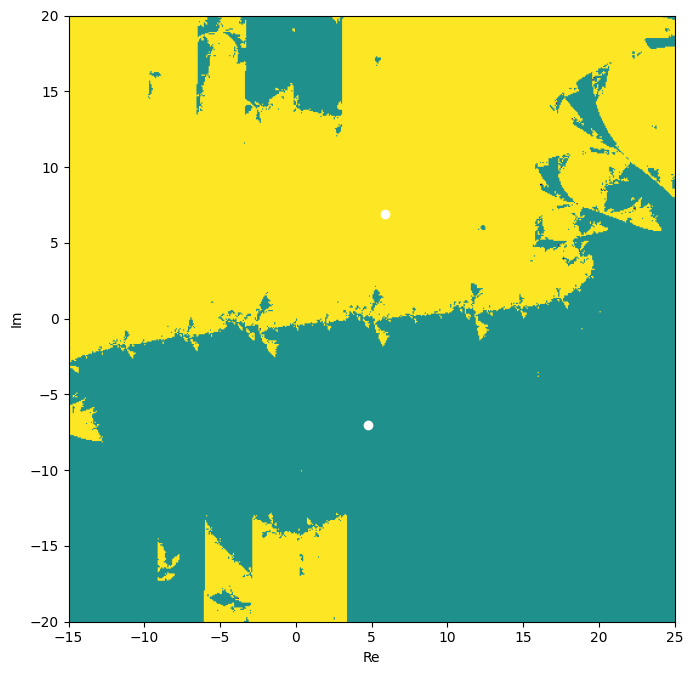

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.890890489714849].


Discovered roots (approx):
root 0: 5.936512+7.283717j
root 1: 4.887575-7.461671j


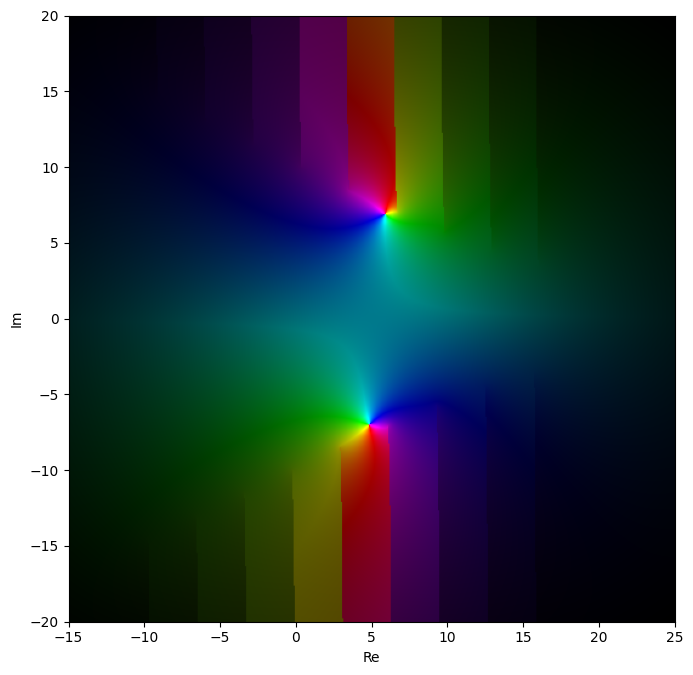

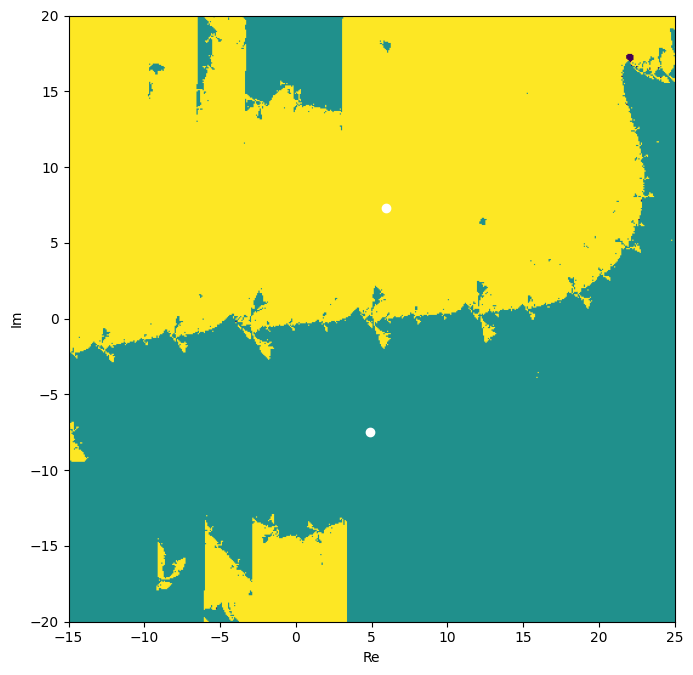

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.11023672619885].


Discovered roots (approx):
root 0: 6.083151+7.731796j
root 1: 5.001074-7.942002j


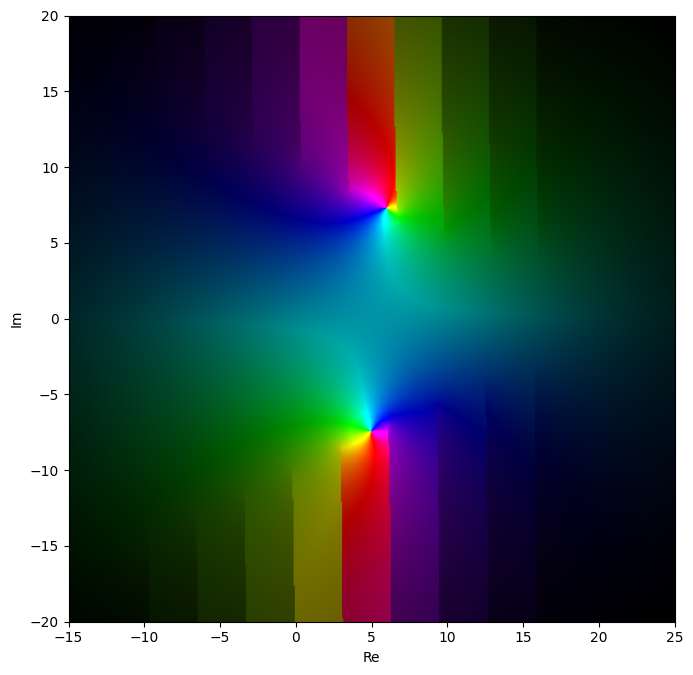

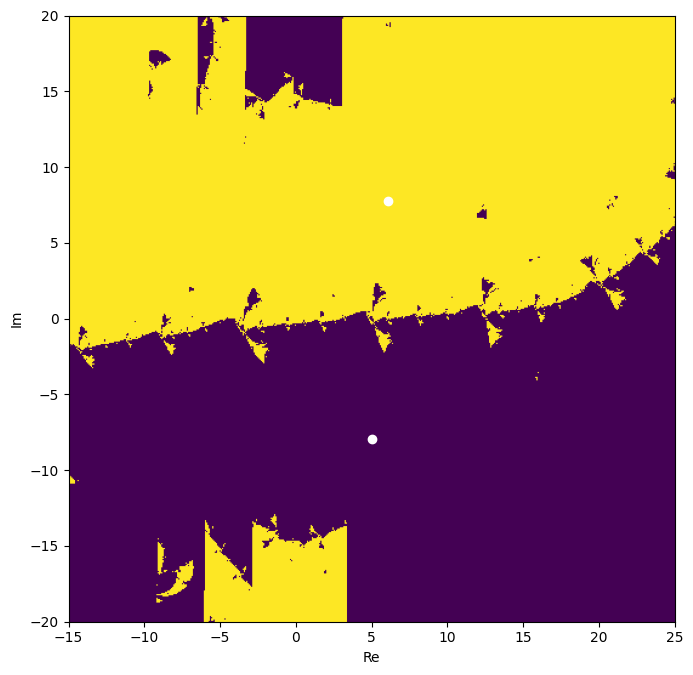

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.655973856811925].


Discovered roots (approx):
root 0: 6.260513+8.292199j
root 1: 5.104541-8.493243j


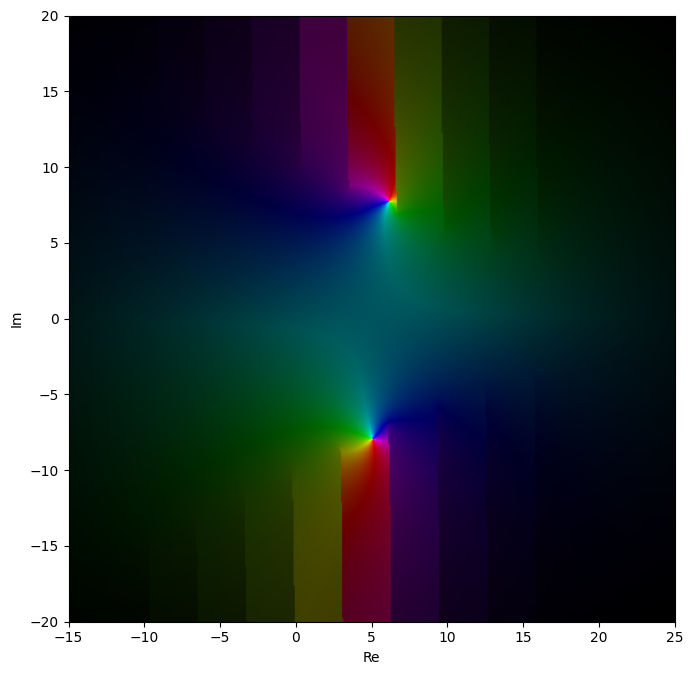

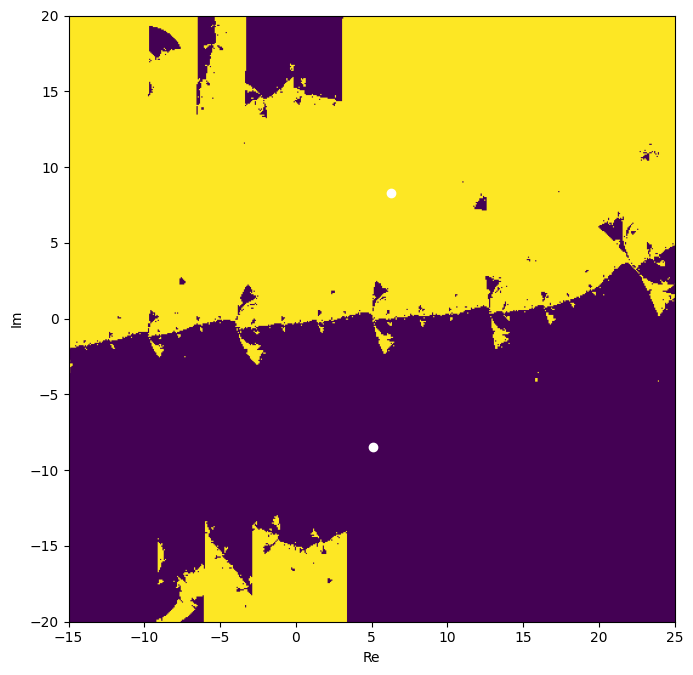

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.865920325636083].


Discovered roots (approx):
root 0: 6.379949+8.997973j
root 1: 5.155269-9.135905j


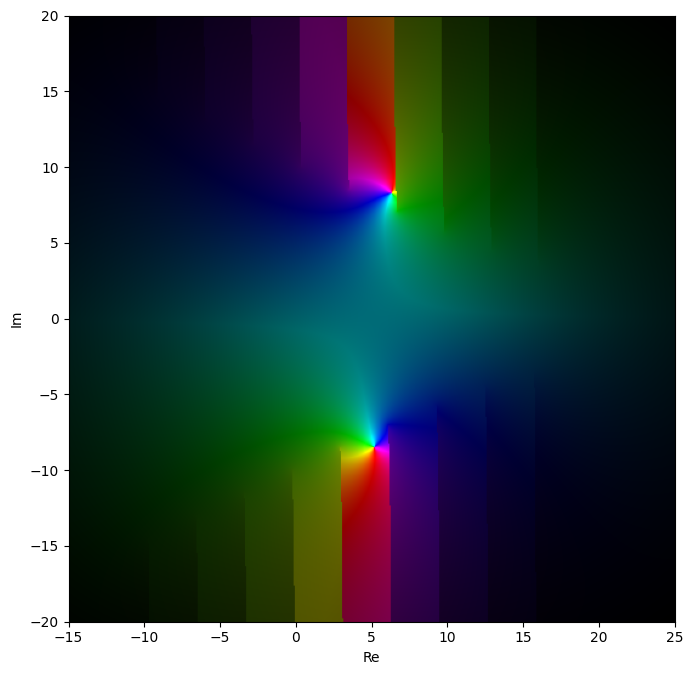

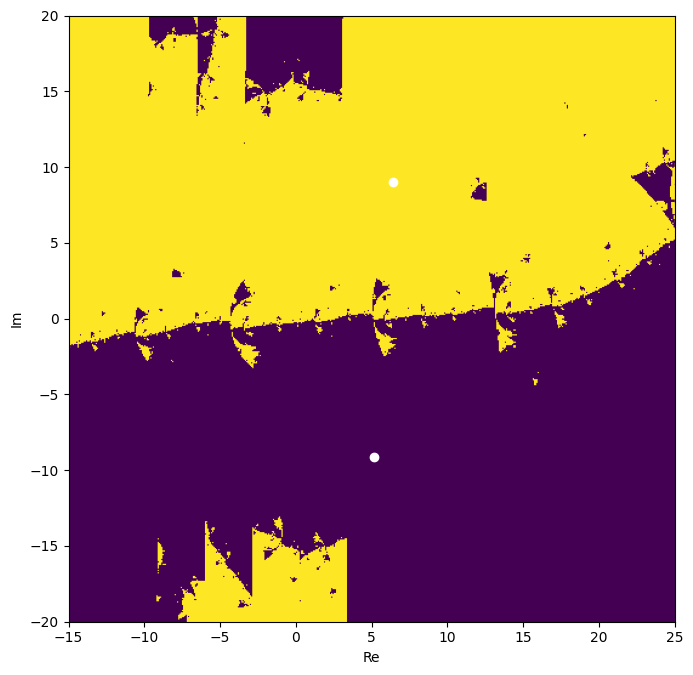

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.9383488556777575].


Discovered roots (approx):
root 0: 6.365396+9.808517j
root 1: 5.109179-9.860031j


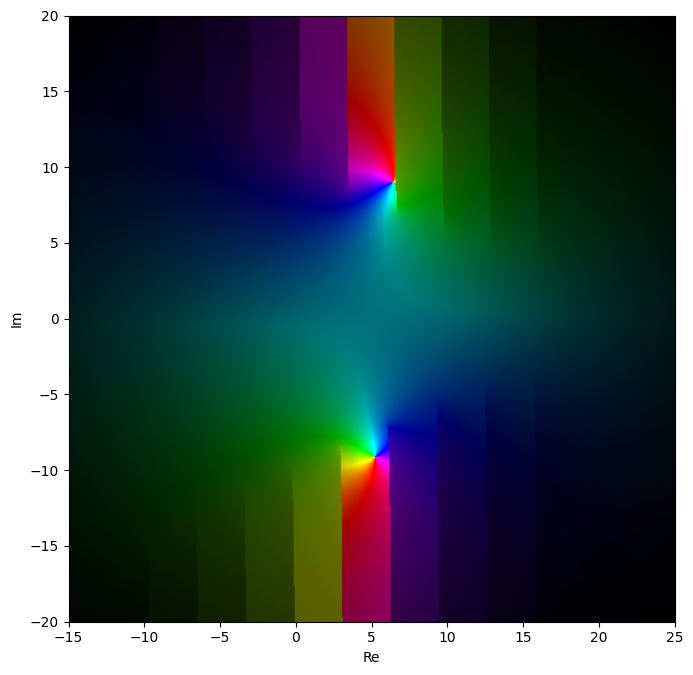

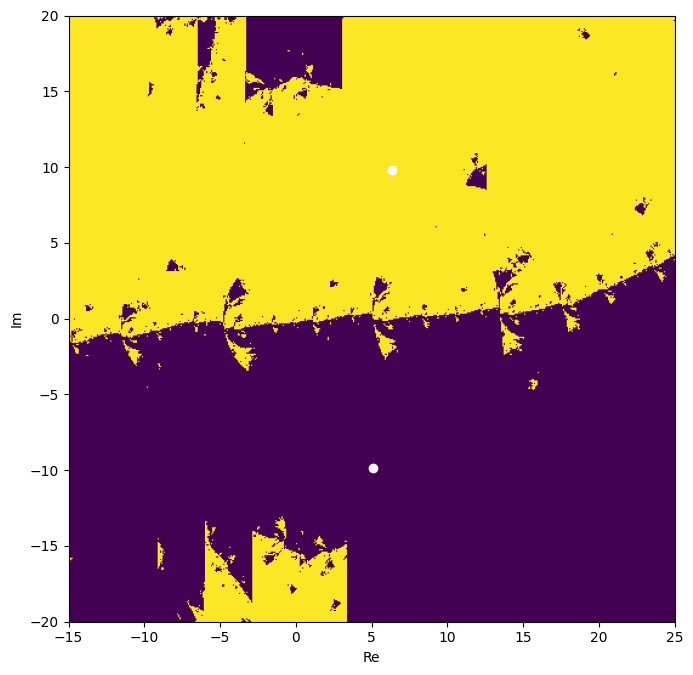

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.9778604163078386].


Discovered roots (approx):
root 0: 4.942622-10.632499j
root 1: 6.193782+10.659635j


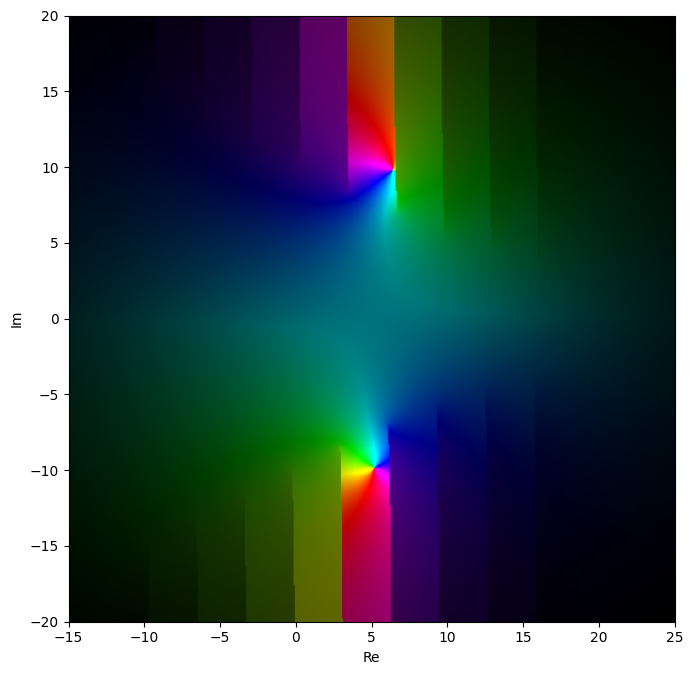

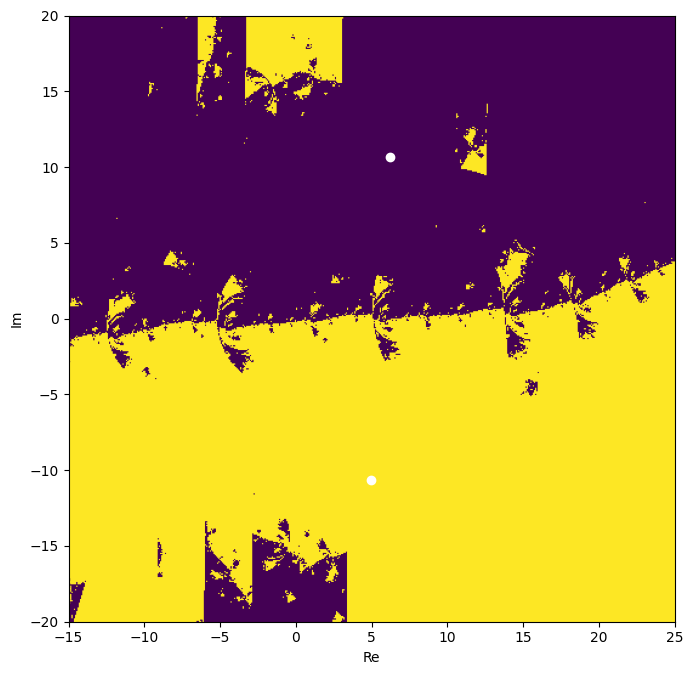

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8449428115267712].


Discovered roots (approx):
root 0: 4.656528-11.414802j
root 1: 5.879504+11.498996j


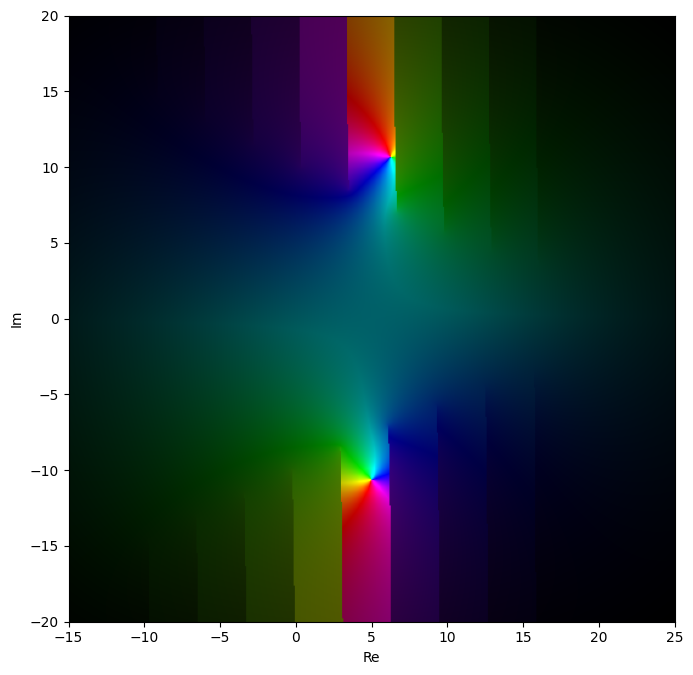

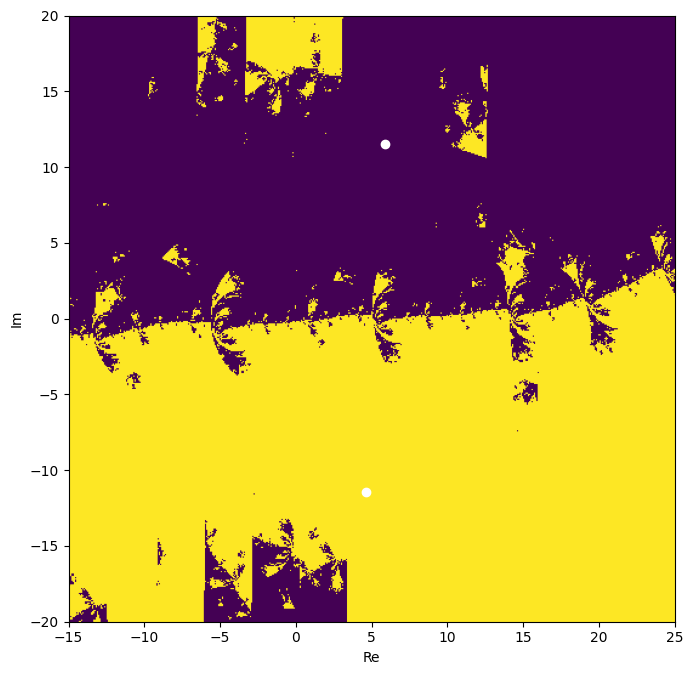

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.823375454156246].


Discovered roots (approx):
root 0: 5.452100+12.295409j
root 1: 4.267318-12.176057j


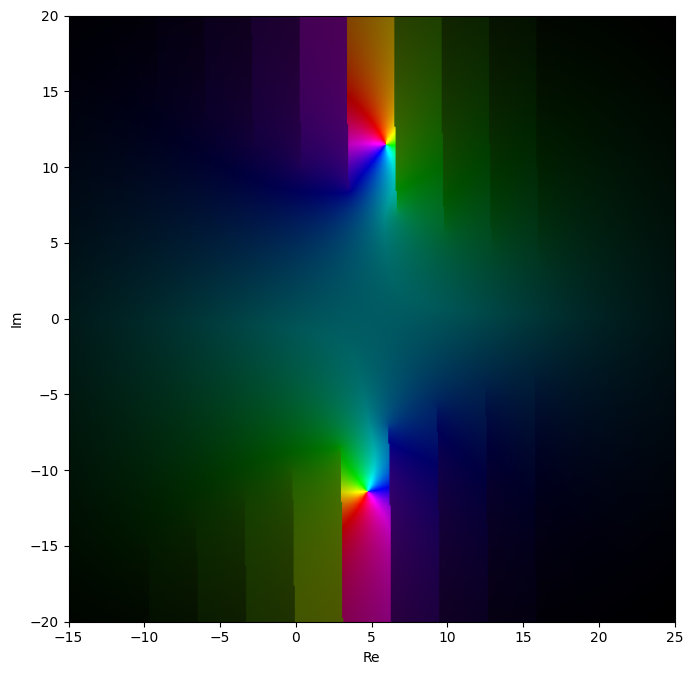

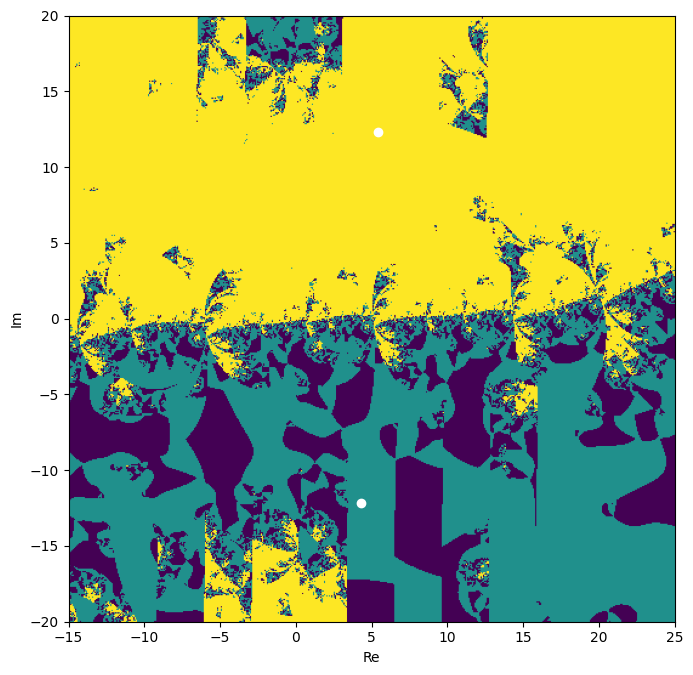

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.7666401707060704].


Discovered roots (approx):
root 0: 4.940856+13.034925j
root 1: 3.795919-12.897095j


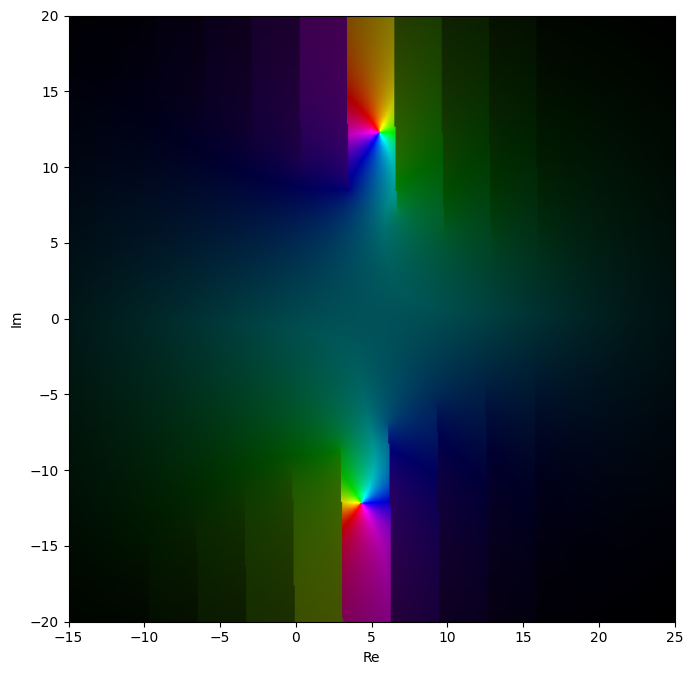

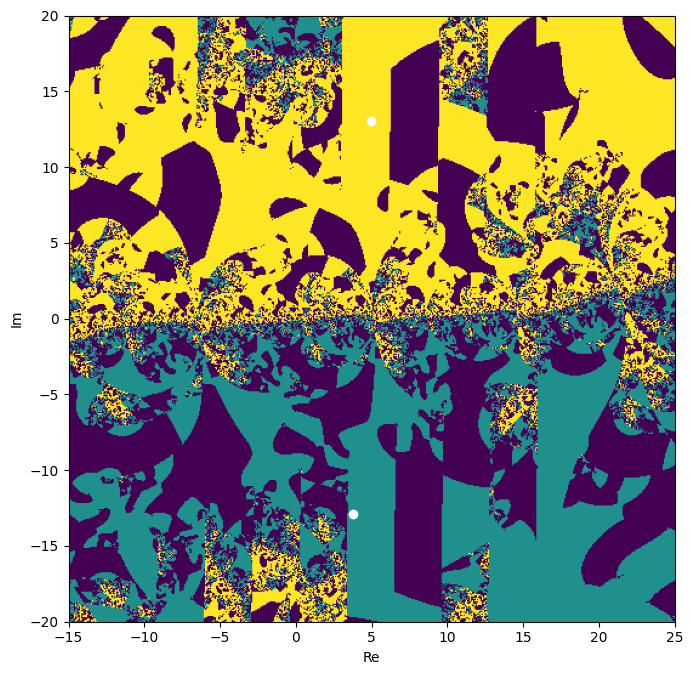

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.832799119540155].


Discovered roots (approx):
root 0: 4.368919+13.713714j
root 1: 3.261371-13.568610j


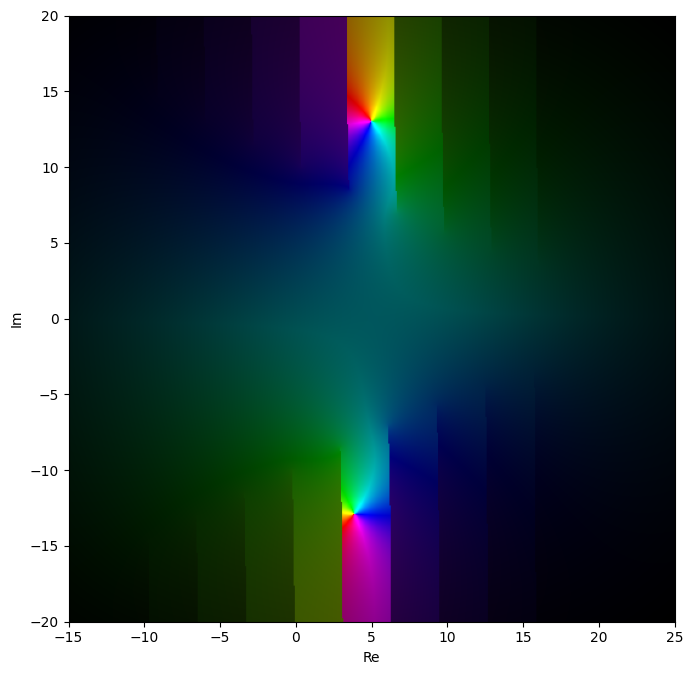

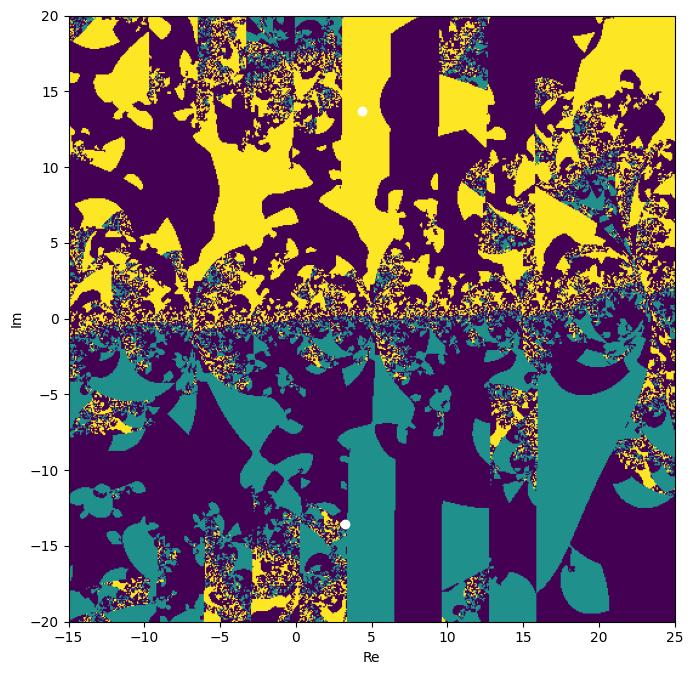

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8677524831560035].


Discovered roots (approx):
root 0: 3.753045+14.332859j


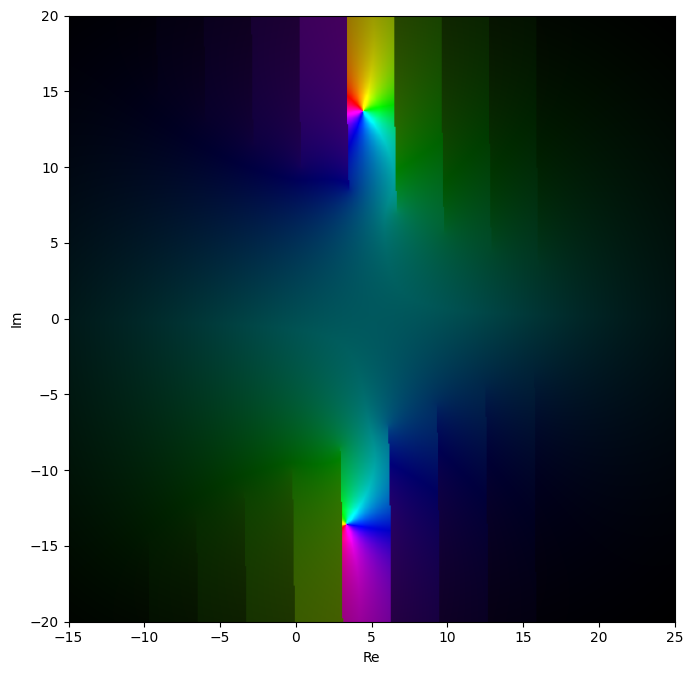

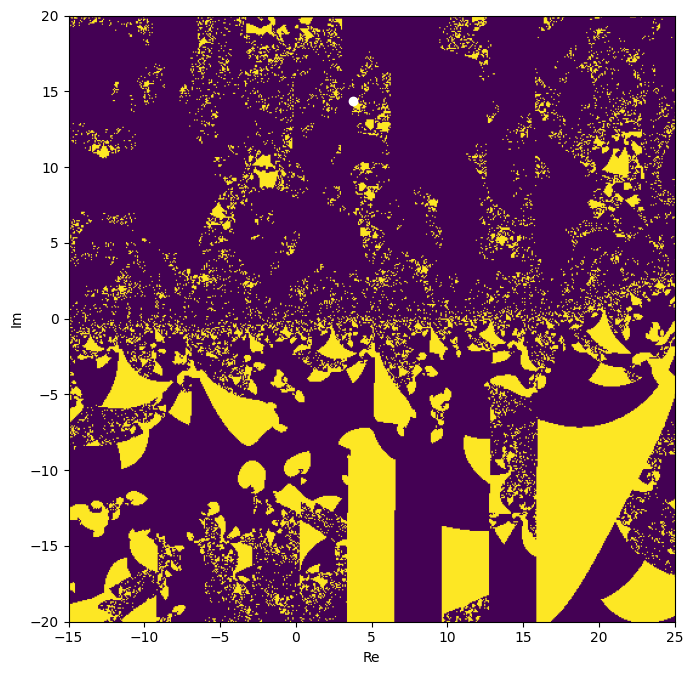

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8716857479252338].


Discovered roots (approx):


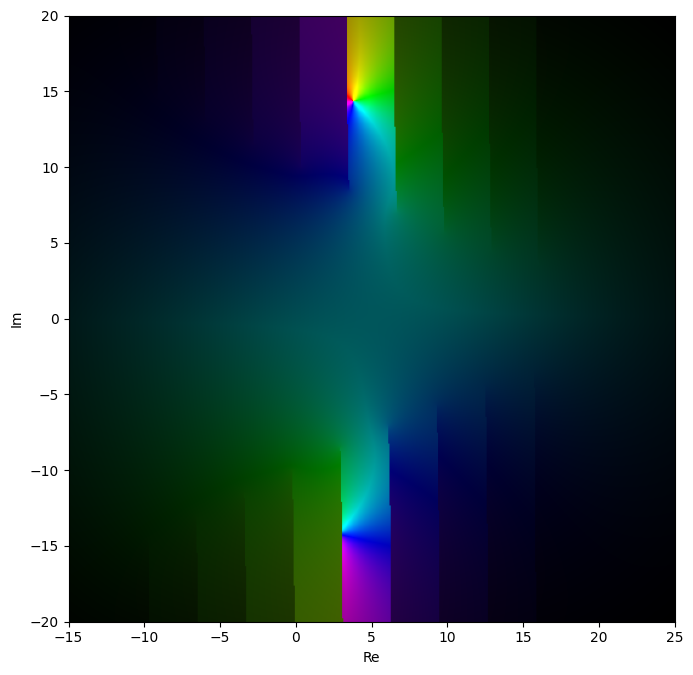

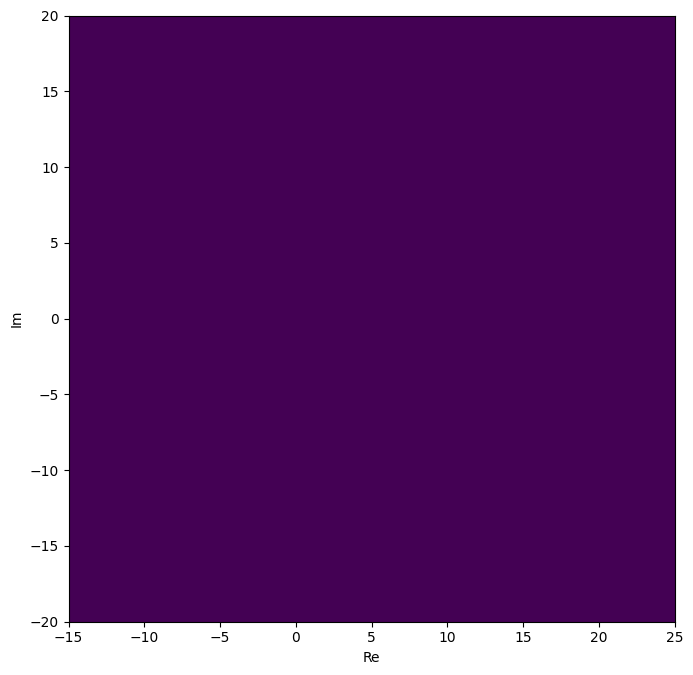

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.9365946929109166].


Discovered roots (approx):


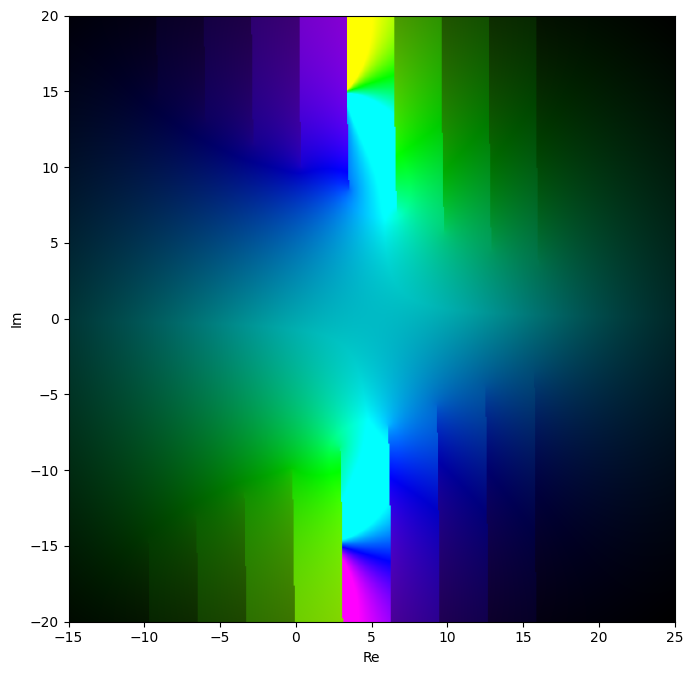

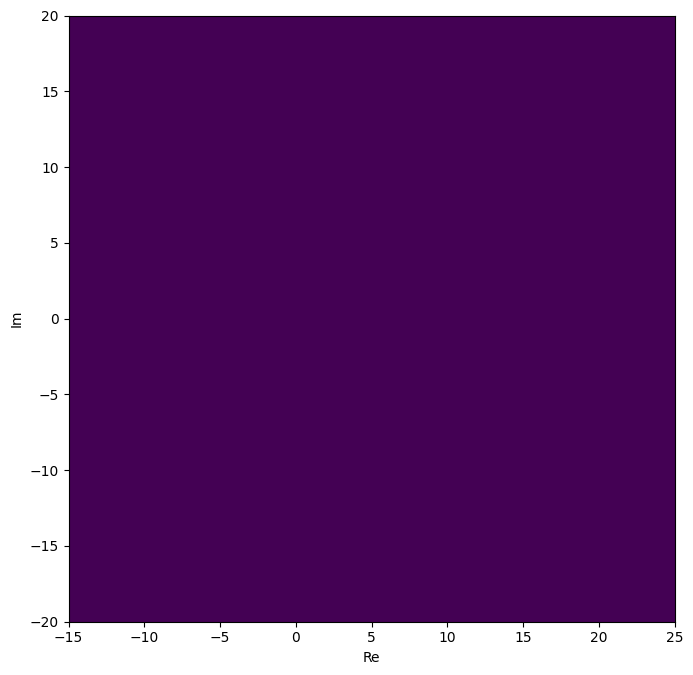

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..6.91852646390259].


Discovered roots (approx):


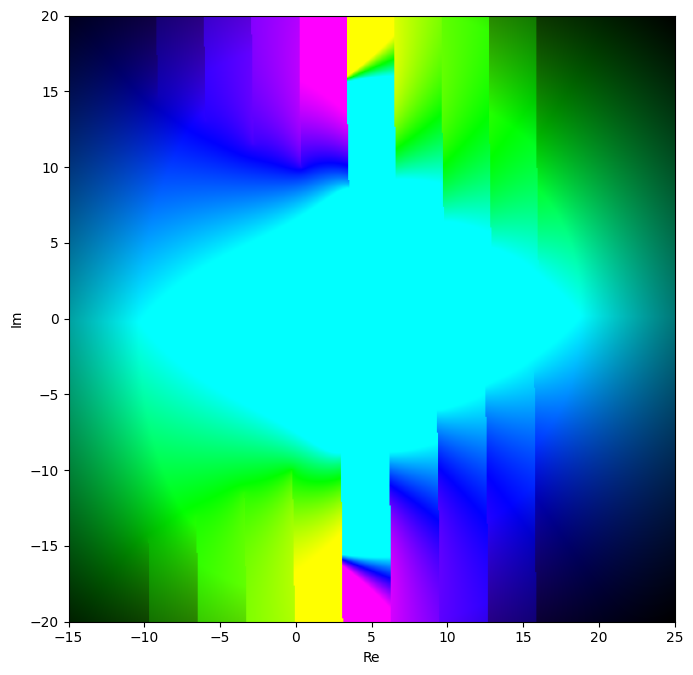

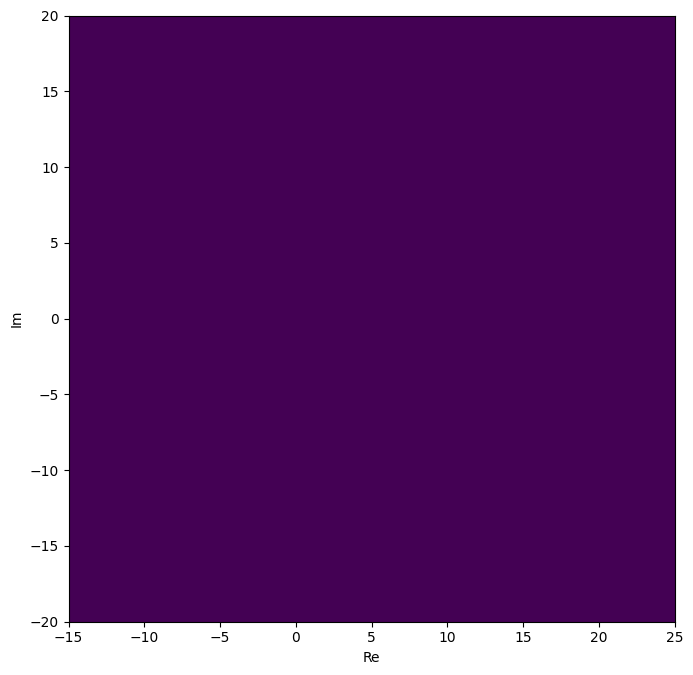

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..51.12466541425979].


Discovered roots (approx):


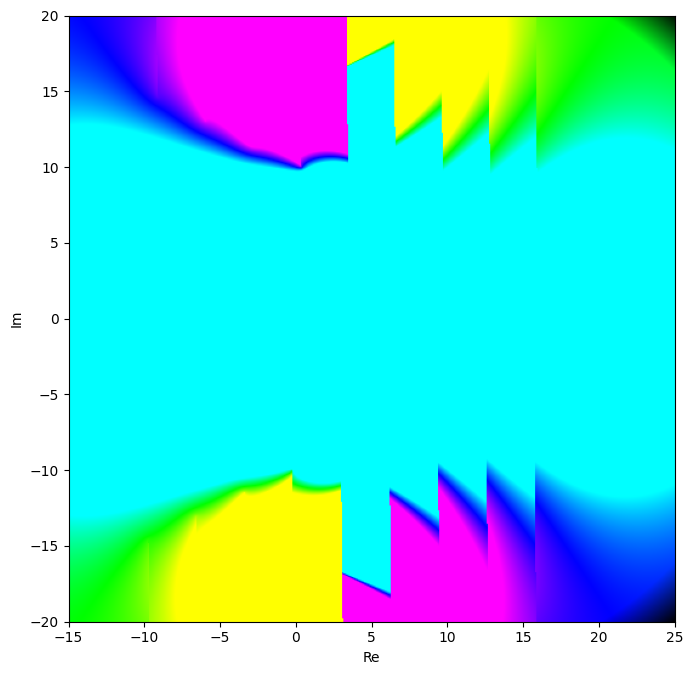

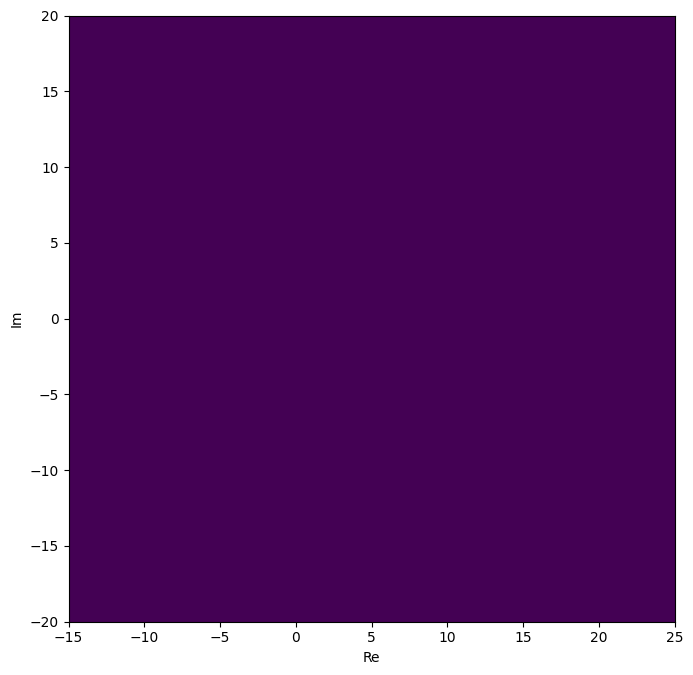

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..12.090417144348].


Discovered roots (approx):


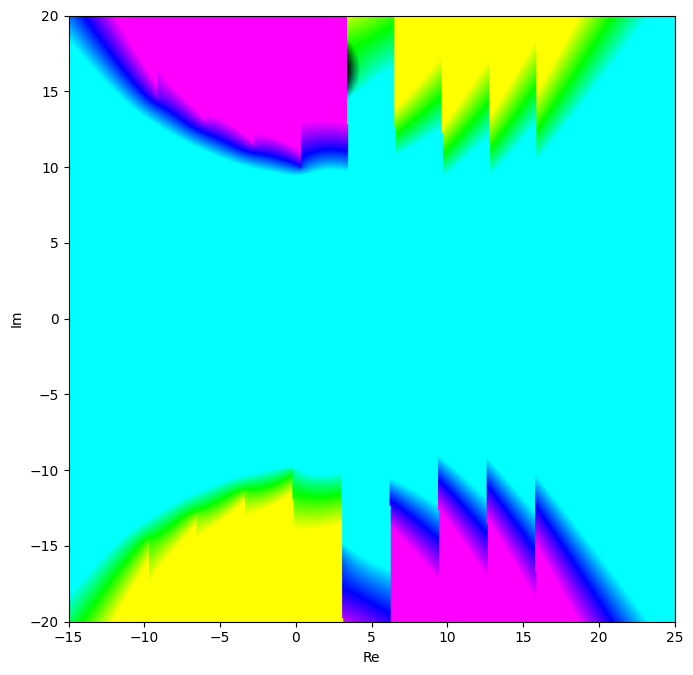

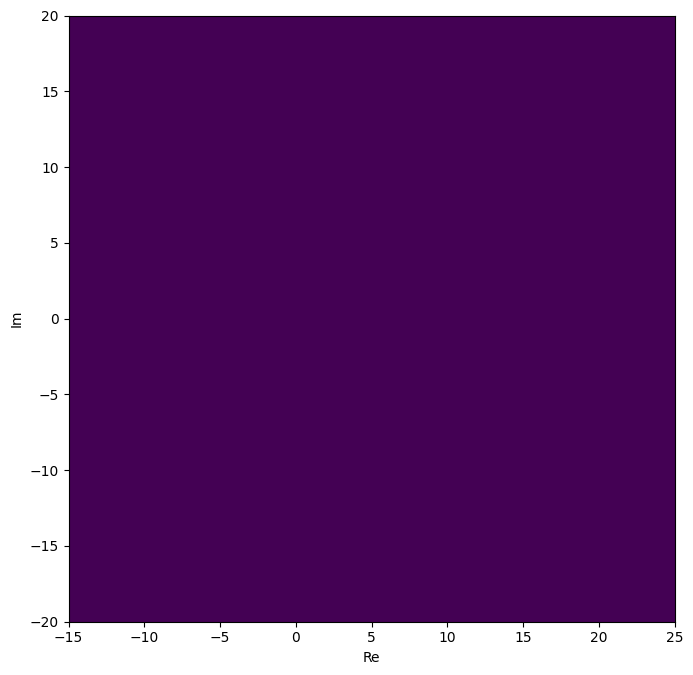

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..5.769691085110063].


Discovered roots (approx):


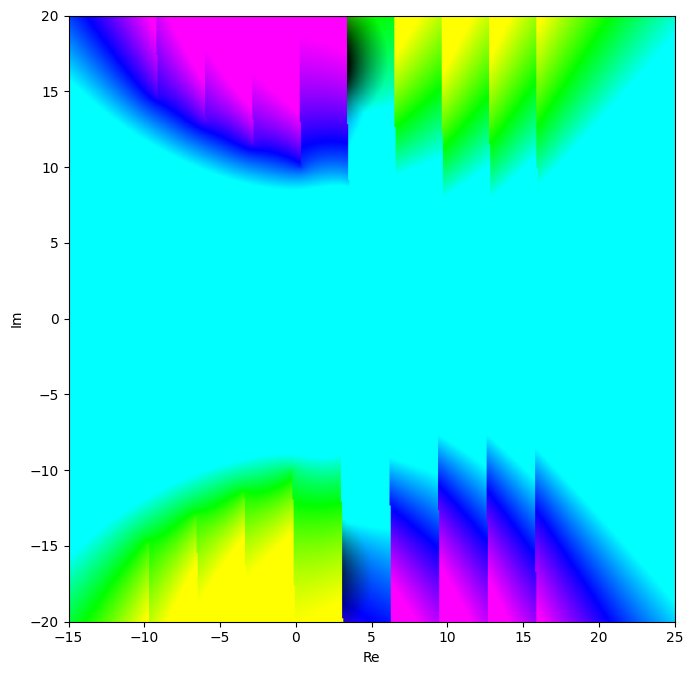

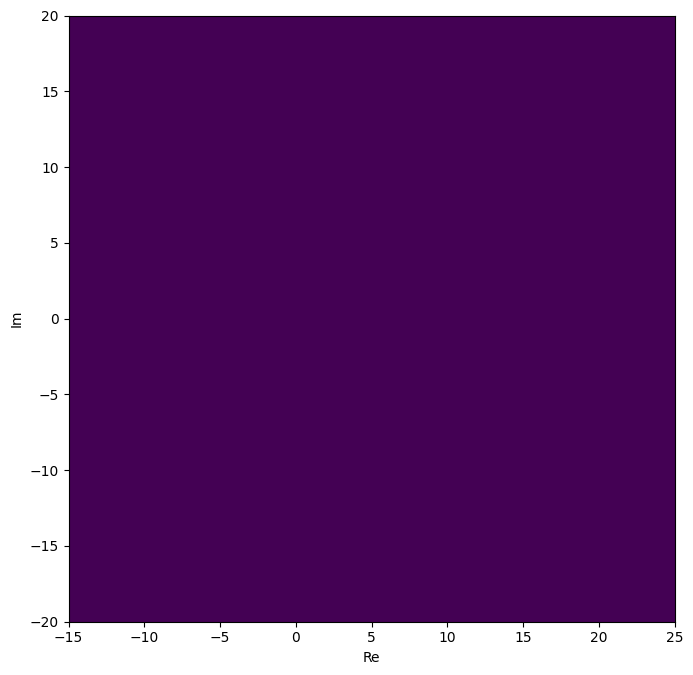

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.8950039152731613].


Discovered roots (approx):


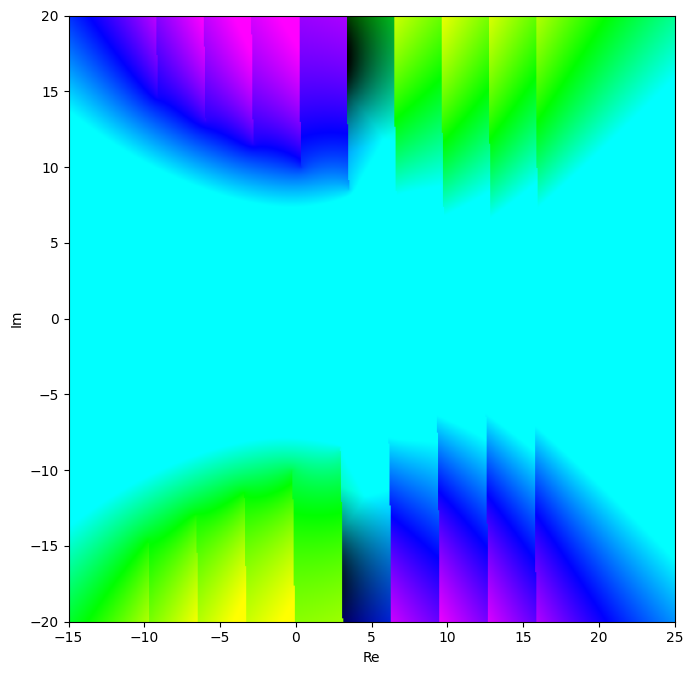

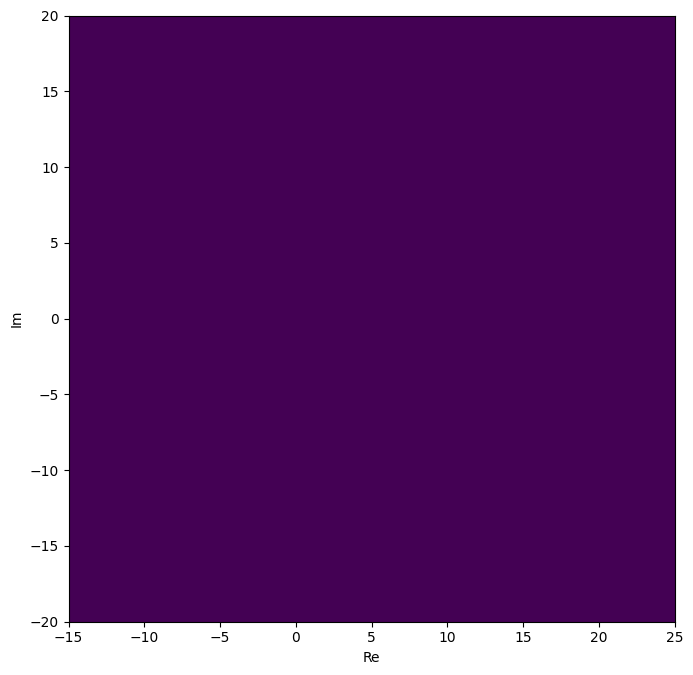

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.982172413707773].


Discovered roots (approx):


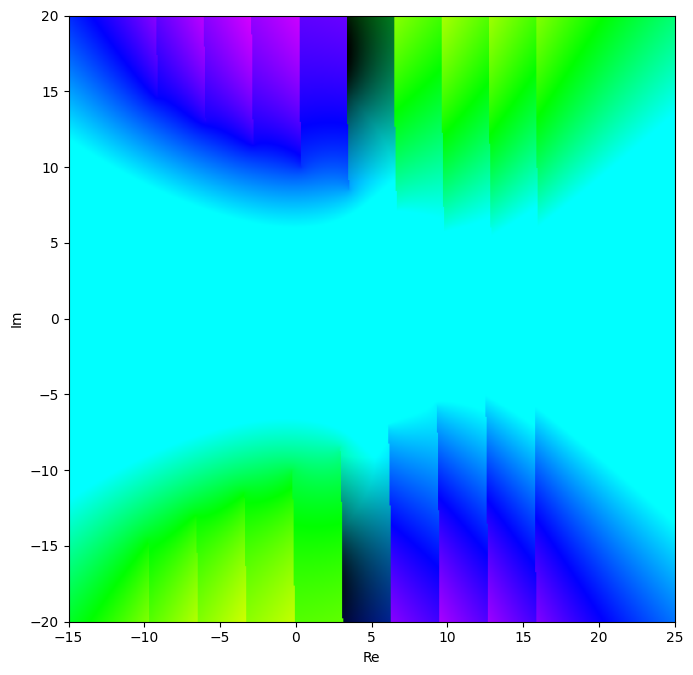

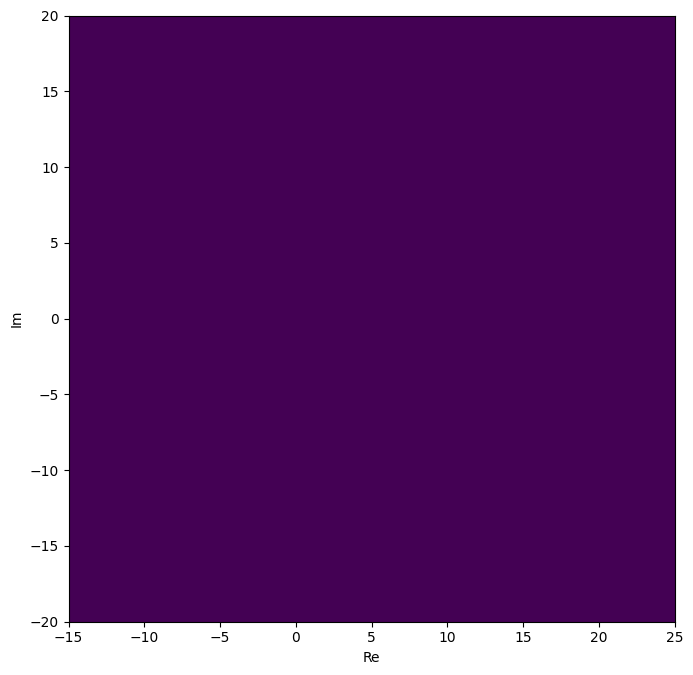

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.43645444985476].


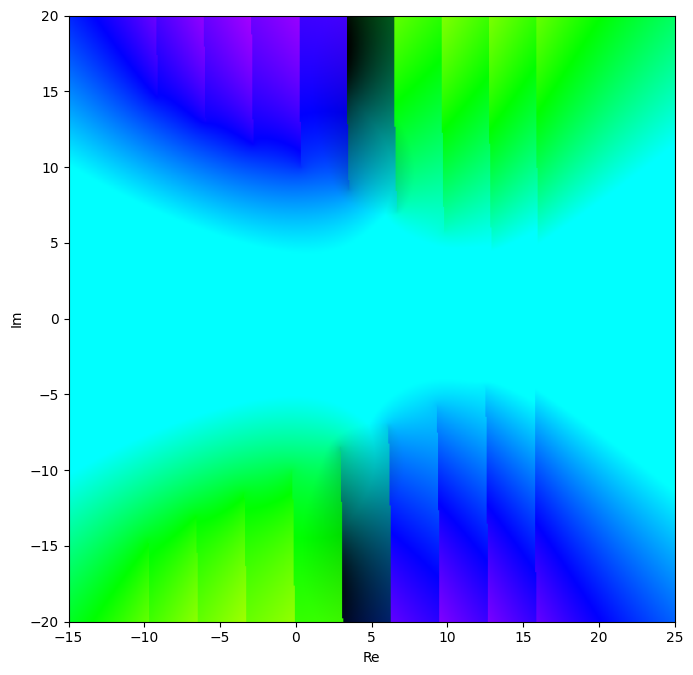

In [6]:
RES = 500
N = 10
xlim = (-N*1.5,N*2.5)
ylim = (-N*2,N*2)
k_hat = [np.array([1/np.sqrt(N),0,0])]*N
qs = [np.array([i-N//2, 1, 0]) for i in range(N)]
ms = [0.5*i-0.1j for i in range(1,N*1)]
Q = -34

for Q in np.linspace(-30,-20,21):
    name = f'10loop_Q={Q}'
    make_images(k_hat, qs, ms, Q, xlim, ylim, RES, name)

